In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# 1. NOISE REDUCTION
def noise_reduction(img):
    # Smooth image to remove random pixel noise
    return cv2.GaussianBlur(img, (5, 5), 1.4)

In [ ]:
# 2. GRADIENT CALCULATION
def gradient_calculation(img):
    # Find edge intensity (magnitude) and direction (angle)
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.hypot(gx, gy)
    mag = (mag / mag.max()) * 255
    ang = np.arctan2(gy, gx)
    return mag.astype(np.uint8), ang

In [ ]:
# 3. NON-MAXIMUM SUPPRESSION
def non_max_suppression(mag, ang):
    # Thin out thick edges to 1-pixel width
    h, w = mag.shape
    out = np.zeros((h, w), dtype=np.int32)
    deg = ang * 180. / np.pi
    deg[deg < 0] += 180

    for i in range(1, h-1):
        for j in range(1, w-1):
            q, r = 255, 255
            # Check neighbors based on edge direction
            if (0 <= deg[i,j] < 22.5) or (157.5 <= deg[i,j] <= 180):
                q, r = mag[i, j+1], mag[i, j-1]
            elif (22.5 <= deg[i,j] < 67.5):
                q, r = mag[i+1, j-1], mag[i-1, j+1]
            elif (67.5 <= deg[i,j] < 112.5):
                q, r = mag[i+1, j], mag[i-1, j]
            elif (112.5 <= deg[i,j] < 157.5):
                q, r = mag[i-1, j-1], mag[i+1, j+1]

            if (mag[i,j] >= q) and (mag[i,j] >= r):
                out[i,j] = mag[i,j]
    return out

In [ ]:
# 4. DOUBLE THRESHOLD
def double_threshold(img, low_r=0.05, high_r=0.15):
    # Identify strong, weak, and non-edge pixels
    high = img.max() * high_r
    low = high * low_r
    res = np.zeros(img.shape, dtype=np.int32)

    strong, weak = 255, 50
    res[img >= high] = strong
    res[(img >= low) & (img < high)] = weak
    return res, weak, strong

In [ ]:
# 5. HYSTERESIS
def hysteresis(img, weak, strong=255):
    # Keep weak pixels only if connected to strong ones
    h, w = img.shape
    for i in range(1, h-1):
        for j in range(1, w-1):
            if img[i,j] == weak:
                if (img[i-1:i+2, j-1:j+2] == strong).any():
                    img[i,j] = strong
                else:
                    img[i,j] = 0
    return img

In [ ]:
# EXTRA: DISPLAY FUNCTION
def DisplayImage(orig, res):
    # Show side-by-side comparison in Colab
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.title("Original"); plt.imshow(orig, cmap='gray')
    plt.subplot(1, 2, 2); plt.title("Canny Edges"); plt.imshow(res, cmap='gray')
    plt.show()

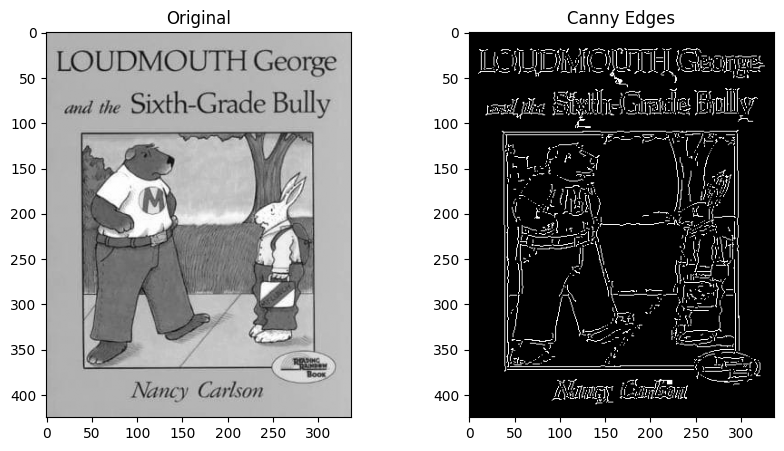

In [ ]:
# --- RUNNING THE CODE ---
img = cv2.imread('test.jpeg', 0)
s1 = noise_reduction(img)
s2_m, s2_a = gradient_calculation(s1)
s3 = non_max_suppression(s2_m, s2_a)
s4, w, s = double_threshold(s3)
final = hysteresis(s4, w, s)
DisplayImage(img, final)